### 오늘 미션
#### IMDB 장르 심화
```
imdb_g = imdb.copy()
imdb_g['Genre'] = \
  imdb_g['Genre'].str.split(',')
imdb_g = imdb_g.explode('Genre')
imdb_g['Genre'] = \
  imdb_g['Genre'].str.strip()
```
- 장르별 평균 평점 bar
- 연도별 평점 추이 scatter
- Gross 정제 후 흥행 vs 평점

#### 타이타닉 + IMDB
##### matplotlib
- 나이 히스토그램
- 성별 생존자 막대
- 나이 vs 요금 산점도
- 등급별 요금 박스플롯
- 탑승항 파이차트

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import platform

In [104]:
if platform.system() == 'Windows':
    plt.rc('font', family = 'Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rc('axes', unicode_minus=False)

In [105]:
TITANIC_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [106]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

##### 나이 히스토그램

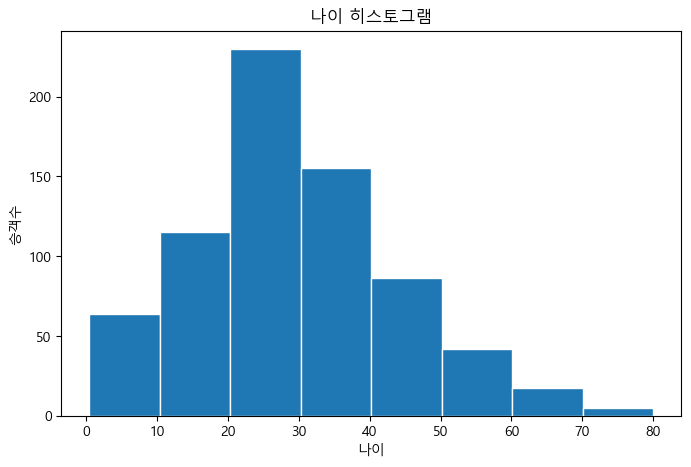

In [107]:
fig, ax = plt.subplots(figsize = (8,5))
ax.hist(titanic['Age'], bins=8, edgecolor='white')

ax.set_title('나이 히스토그램')
ax.set_xlabel('나이')
ax.set_ylabel('승객수')
plt.savefig('./image/titanic_histogram.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

##### 성별 생존자 막대그래프

In [108]:
surv = titanic[titanic['Survived'] == 1]
surv_sex = surv.groupby('Sex')['Survived'].count()
surv_sex

Sex
female    233
male      109
Name: Survived, dtype: int64

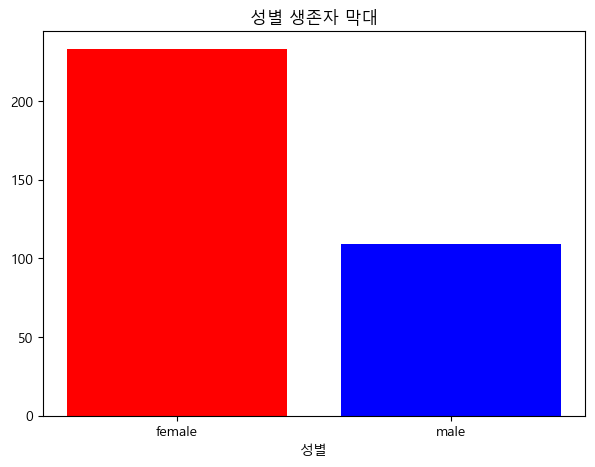

In [109]:
fig, ax = plt.subplots(figsize=(7,5))
ax.bar(surv_sex.index, surv_sex.values,
       color=['red','blue'])
ax.set_title('성별 생존자 막대')
ax.set_xlabel('성별')
plt.savefig('./image/titanic_bar.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

##### 나이 vs 요금 산점도

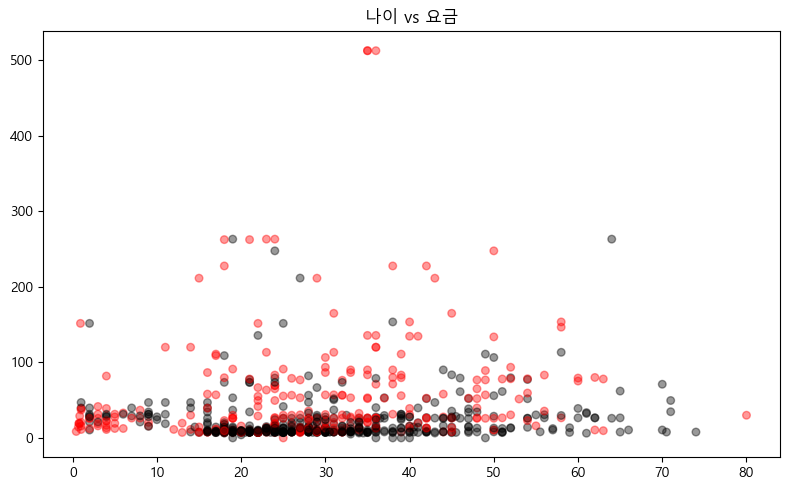

In [110]:
titanic[['Age','Fare']].isnull().sum()
af = titanic[['Age','Fare','Survived']].dropna()
colors = af['Survived'].map({0:'black', 1:'red'})

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(af['Age'],
           af['Fare'],
           c=colors, alpha=0.4, s=30)
ax.set_title('나이 vs 요금')
plt.savefig('./image/titanic_scatter.png',
            dpi=150,
            bbox_inches='tight')
plt.tight_layout()
plt.show()

##### 등급별 요금 박스플롯

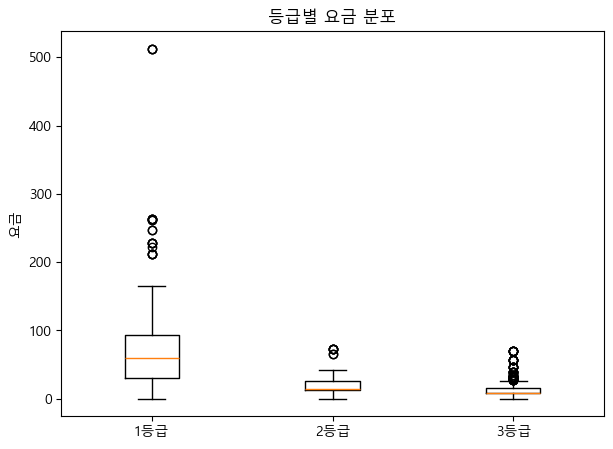

In [111]:
t_class = [titanic[titanic['Pclass']==c]['Fare'].dropna()
            for c in [1,2,3]]
fig, ax = plt.subplots(figsize = (7,5))
ax.boxplot(t_class, tick_labels=['1등급','2등급','3등급'])
ax.set_ylabel('요금')
ax.set_title('등급별 요금 분포')
plt.savefig('./image/titanic_box.png',
            dpi=150,
            bbox_inches='tight')
plt.show()


##### 탑승항 파이차트

In [112]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

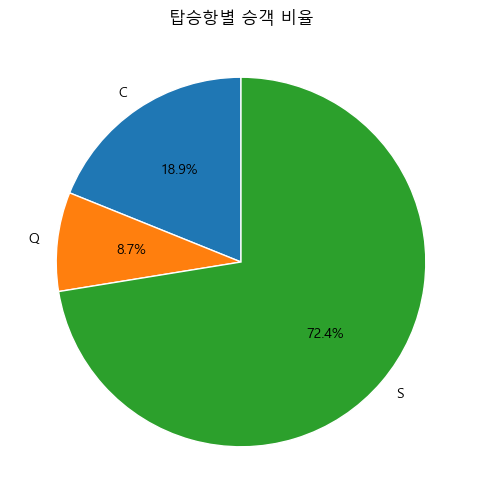

In [113]:
emberked = titanic['Embarked'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6,6))
ax.pie(emberked.values,
       labels=emberked.index,
       autopct='%1.1f%%',
       startangle=90,
       wedgeprops=dict(edgecolor='white'))
ax.set_title('탑승항별 승객 비율')
plt.savefig('./image/titanic_pie.png',
            dpi=150,
            bbox_inches='tight')
plt.show()


##### plotly
- IMDB 평점 histogram
- 투표 수 vs 평점 scatter
- HTML 저장

In [114]:
imdb = pd.read_csv('imdb_top_1000.csv')
imdb.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 125.1 KB


In [115]:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='str')

##### IMDB 평점 histogram

In [116]:
fig = px.histogram(
    imdb,
    x='IMDB_Rating',
    nbins=10,
    title='IMDB 평점 분포',
    template='simple_white'
)

fig.show()
fig.write_html('./image/imdb_histogram.html')

##### 투표 수 vs 평점 scatter

In [117]:
fig = px.scatter(
    imdb,
    x='No_of_Votes',
    y="IMDB_Rating",
    hover_name='Series_Title',
    hover_data=['No_of_Votes',
                'Genre'],
    title='투표 수 vs IMDB 평점',
    template='simple_white',
    opacity=0.6
)
fig.show()
fig.write_html('./image/imdb_scatter.html')

#### 서울아파트
- 월별 평균 가격 꺾은선
- 월별 거래 건수 막대
- 구별 평균 가격 수평 막대
- 최근 3년 가격 추이
- HTML 저장

In [118]:
seoul = pd.read_csv('seoul_apartment.csv')
seoul.info()

<class 'pandas.DataFrame'>
RangeIndex: 1260226 entries, 0 to 1260225
Data columns (total 13 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   NO        1260226 non-null  int64  
 1   시군구       1260226 non-null  str    
 2   번지        1260226 non-null  str    
 3   본번        1260226 non-null  int64  
 4   부번        1260226 non-null  int64  
 5   단지명       1260226 non-null  str    
 6   전용면적(㎡)   1260226 non-null  float64
 7   계약년월      1260226 non-null  int64  
 8   계약일       1260226 non-null  int64  
 9   거래금액(만원)  1260226 non-null  int64  
 10  층         1260226 non-null  int64  
 11  건축년도      1260226 non-null  int64  
 12  도로명       1260226 non-null  str    
dtypes: float64(1), int64(8), str(4)
memory usage: 125.0 MB


##### 월별 평균 가격 꺾은선

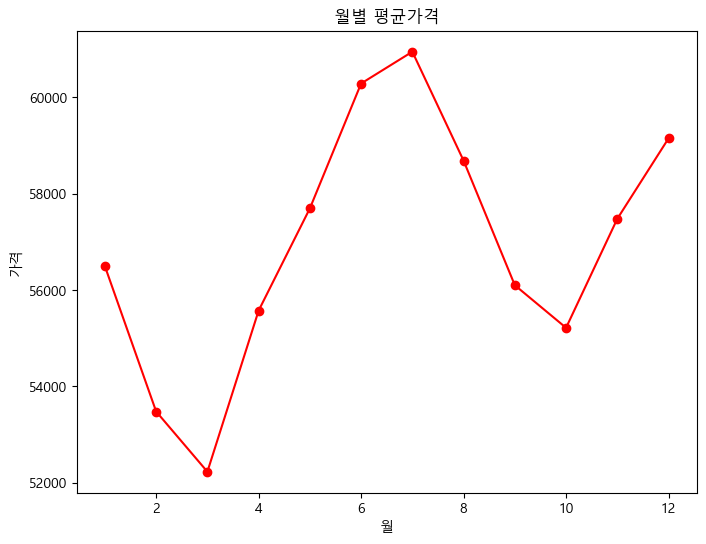

In [156]:
seoul_df=seoul[['거래금액(만원)','계약년월']].copy()
seoul_df['월'] = seoul_df['계약년월'] % 100
month_df = seoul_df.groupby('월')[['거래금액(만원)']].mean()
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(month_df.index,month_df.values, color='red', marker='o')
plt.title('월별 평균가격')
plt.xlabel('월')
plt.ylabel('가격')
plt.savefig('./image/seoul_line.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

##### 월별 거래 건수 막대

In [148]:
month_count_df

,월,계약일
0,1,93015
1,2,97190
2,3,119817
3,4,105436
4,5,105356
5,6,115630
6,7,113717
7,8,107627
8,9,107413
9,10,113976


In [155]:
seoul_df=seoul[['계약일','계약년월']].copy()
seoul_df['월'] = seoul_df['계약년월'] % 100
month_count_df = seoul_df.groupby('월')[['계약일']].count()
month_count_df = month_count_df.reset_index()
fig = px.bar(
    x=month_count_df['월'],
    y=month_count_df['계약일'], title='월별 거래 건수',
    labels={
        '월': '월',
        '계약일': '거래 건수'}
)
# x행
fig.update_xaxes(
    tickmode='array',
    tickvals=list(range(1, 13)),
    ticktext=[f'{m}월' for m in range(1, 13)]
)
fig.write_html('./image/seoul_bar.html')
fig.show()